In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Style settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv(r'C:\Users\PC\OneDrive\Desktop\Movie Credits Analysis using EDA\data\credits.csv')
df.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [5]:
df.isnull().sum()

cast    0
crew    0
id      0
dtype: int64

In [6]:
def convert(text):
    return ast.literal_eval(text)

df['cast'] = df['cast'].apply(convert)
df['crew'] = df['crew'].apply(convert)

In [7]:
def get_top_cast(cast_list):
    names = []
    for i in cast_list[:3]:
        names.append(i['name'])
    return names

df['top_cast'] = df['cast'].apply(get_top_cast)

In [11]:
def get_director(crew_list):
    for i in crew_list:
        if i['job'] == 'Director':
            return i['name']
    return np.nan

df['director'] = df['crew'].apply(get_director)

In [13]:
df.columns

Index(['cast', 'crew', 'id', 'top_cast', 'director'], dtype='object')

In [14]:
df[['top_cast', 'director']].head()

,top_cast,director
0,"[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter
1,"[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston
2,"[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch
3,"[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker
4,"[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer


In [16]:
all_actors = []

for cast in df['top_cast']:
    all_actors.extend(cast)

actor_series = pd.Series(all_actors)

top_actors = actor_series.value_counts().head(10)

In [17]:
actor_series.head()

0         Tom Hanks
1         Tim Allen
2       Don Rickles
3    Robin Williams
4     Jonathan Hyde
dtype: object

In [18]:
unique_actors = len(actor_series.unique())

top_actor_name = top_actors.index[0]
top_actor_count = top_actors.iloc[0]

print("🎭 ACTOR INSIGHTS")
print(f"Total Unique Actors: {unique_actors}")
print(f"Most Frequent Actor: {top_actor_name}")
print(f"Number of Movies: {top_actor_count}")

🎭 ACTOR INSIGHTS
Total Unique Actors: 47481
Most Frequent Actor: John Wayne
Number of Movies: 106


In [19]:
# Director insights
unique_directors = df['director'].nunique()

top_director_name = df['director'].value_counts().index[0]
top_director_count = df['director'].value_counts().iloc[0]

print("🎬 DIRECTOR INSIGHTS")
print(f"Total Unique Directors: {unique_directors}")
print(f"Most Active Director: {top_director_name}")
print(f"Number of Movies: {top_director_count}")

🎬 DIRECTOR INSIGHTS
Total Unique Directors: 17572
Most Active Director: John Ford
Number of Movies: 66


In [20]:
# Create cast size column
df['cast_size'] = df['cast'].apply(len)

# Stats
avg_cast = df['cast_size'].mean()
max_cast = df['cast_size'].max()
min_cast = df['cast_size'].min()

print("📏 CAST SIZE INSIGHTS")
print(f"Average Cast Size: {round(avg_cast,2)}")
print(f"Maximum Cast Size: {max_cast}")
print(f"Minimum Cast Size: {min_cast}")

📏 CAST SIZE INSIGHTS
Average Cast Size: 12.37
Maximum Cast Size: 313
Minimum Cast Size: 0


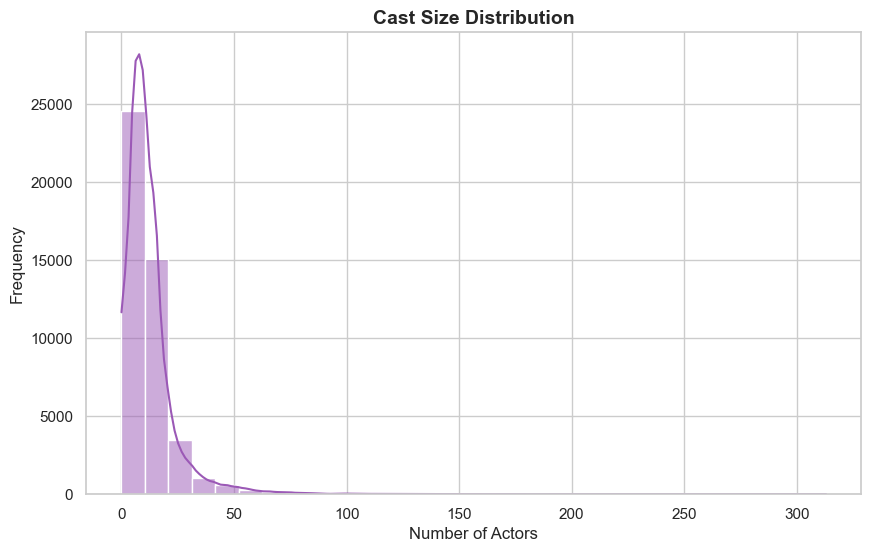

In [35]:
plt.figure()

sns.histplot(df['cast_size'], bins=30, kde=True, color="#9b59b6")

plt.title("Cast Size Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Actors")
plt.ylabel("Frequency")

plt.show()

In [22]:
top10_total = top_actors.sum()
all_total = actor_series.count()

percentage = (top10_total / all_total) * 100

print("📊 ACTOR DOMINANCE")
print(f"Top 10 actors contribute {round(percentage,2)}% of total appearances")

📊 ACTOR DOMINANCE
Top 10 actors contribute 0.63% of total appearances


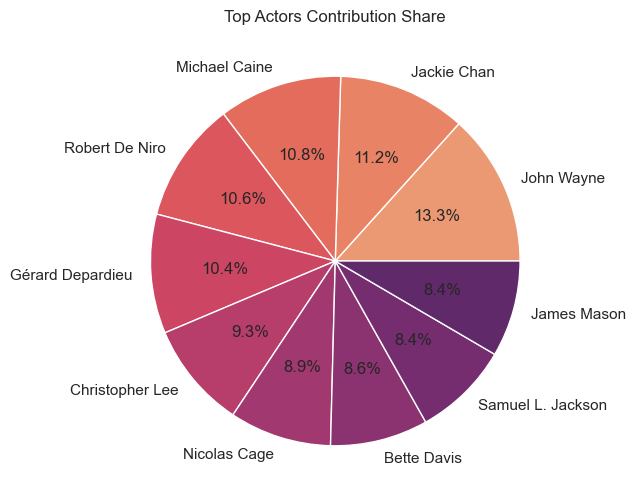

In [36]:
plt.figure()

colors = sns.color_palette("flare", len(top_actors))

plt.pie(top_actors.values, labels=top_actors.index, autopct='%1.1f%%', colors=colors)
plt.title("Top Actors Contribution Share")

plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_7528\1361267606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette=colors)


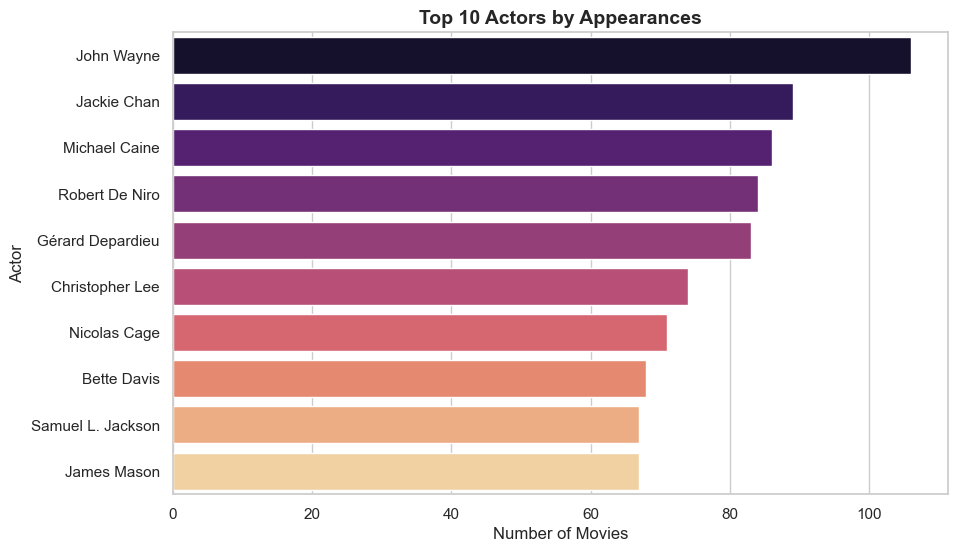

In [37]:
plt.figure()

colors = sns.color_palette("magma", len(top_actors))
sns.barplot(x=top_actors.values, y=top_actors.index, palette=colors)

plt.title("Top 10 Actors by Appearances", fontsize=14, fontweight='bold')
plt.xlabel("Number of Movies")
plt.ylabel("Actor")

plt.show()

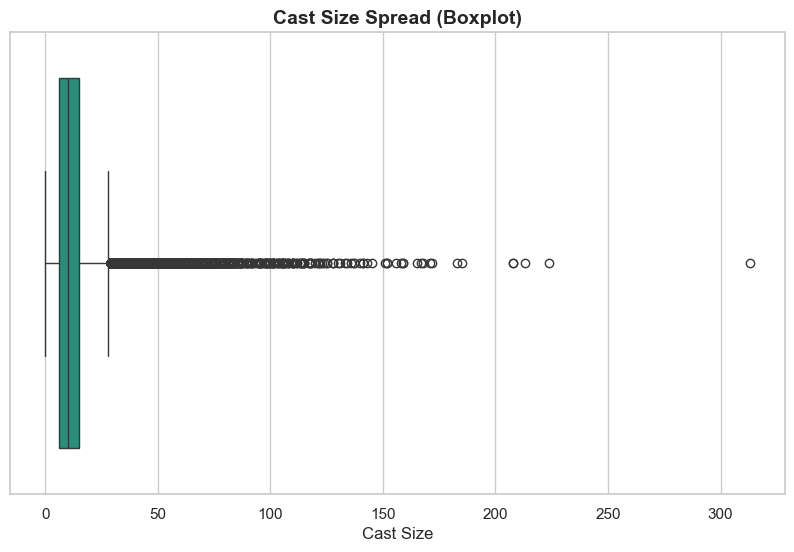

In [38]:
plt.figure()

sns.boxplot(x=df['cast_size'], color="#16a085")

plt.title("Cast Size Spread (Boxplot)", fontsize=14, fontweight='bold')
plt.xlabel("Cast Size")

plt.show()

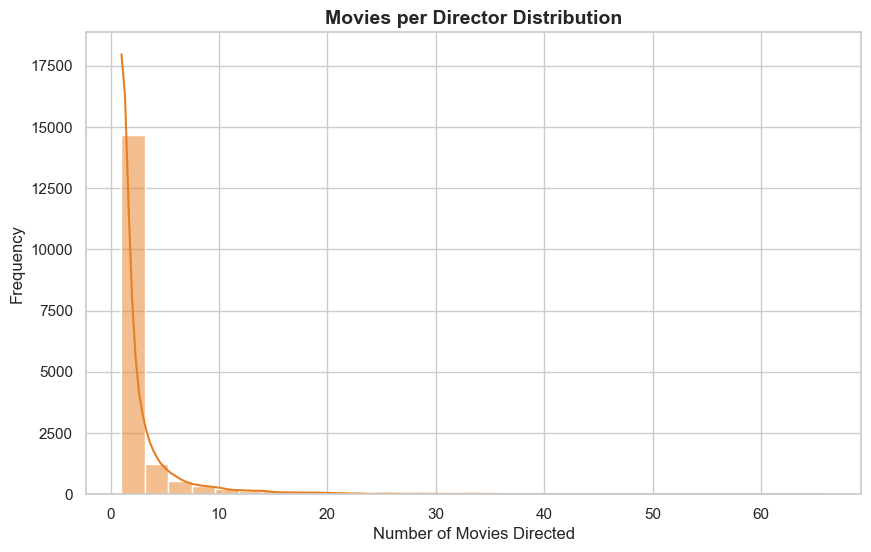

In [39]:
director_counts = df['director'].value_counts()

plt.figure()

sns.histplot(director_counts, bins=30, kde=True, color="#e67e22")

plt.title("Movies per Director Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Movies Directed")
plt.ylabel("Frequency")

plt.show()

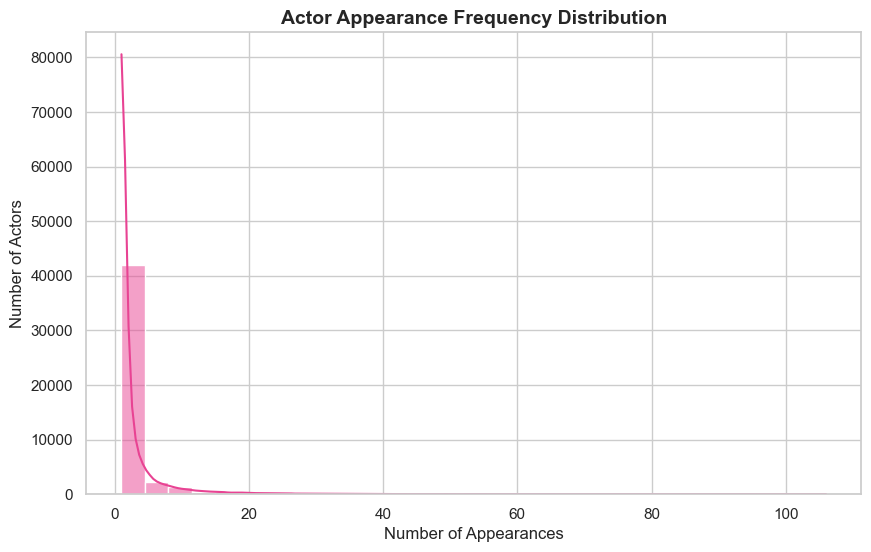

In [40]:
plt.figure()

sns.histplot(actor_series.value_counts(), bins=30, kde=True, color="#e84393")

plt.title("Actor Appearance Frequency Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Appearances")
plt.ylabel("Number of Actors")

plt.show()

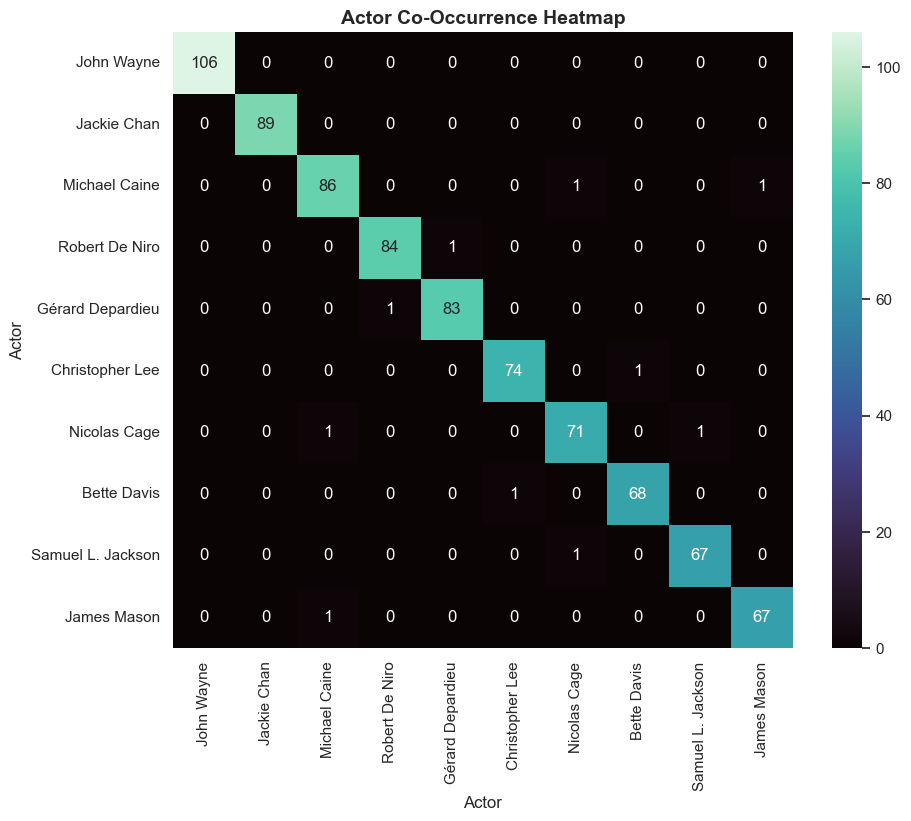

In [41]:
top_actor_list = top_actors.index.tolist()

matrix = pd.DataFrame(0, index=top_actor_list, columns=top_actor_list)

for cast in df['top_cast']:
    for i in cast:
        for j in cast:
            if i in top_actor_list and j in top_actor_list:
                matrix.loc[i, j] += 1

plt.figure(figsize=(10,8))

sns.heatmap(matrix, cmap="mako", annot=True, fmt="d")

plt.title("Actor Co-Occurrence Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Actor")
plt.ylabel("Actor")

plt.show()

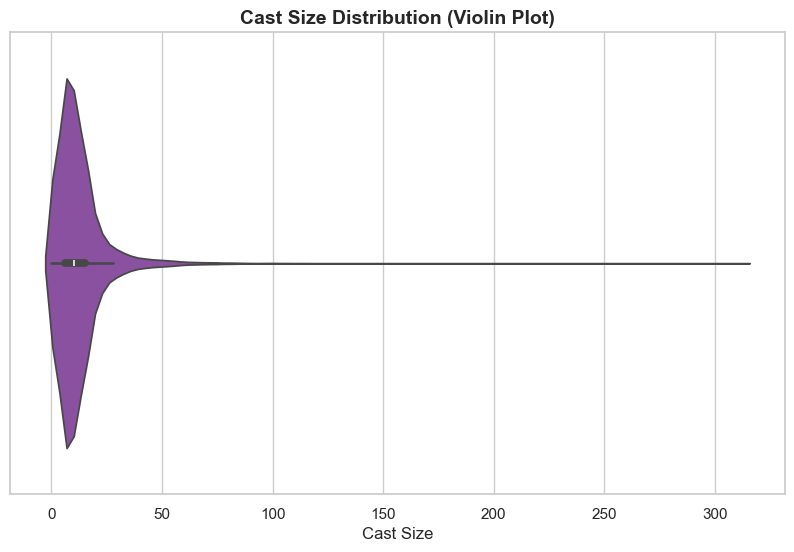

In [42]:
plt.figure()

sns.violinplot(x=df['cast_size'], color="#8e44ad")

plt.title("Cast Size Distribution (Violin Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Cast Size")

plt.show()

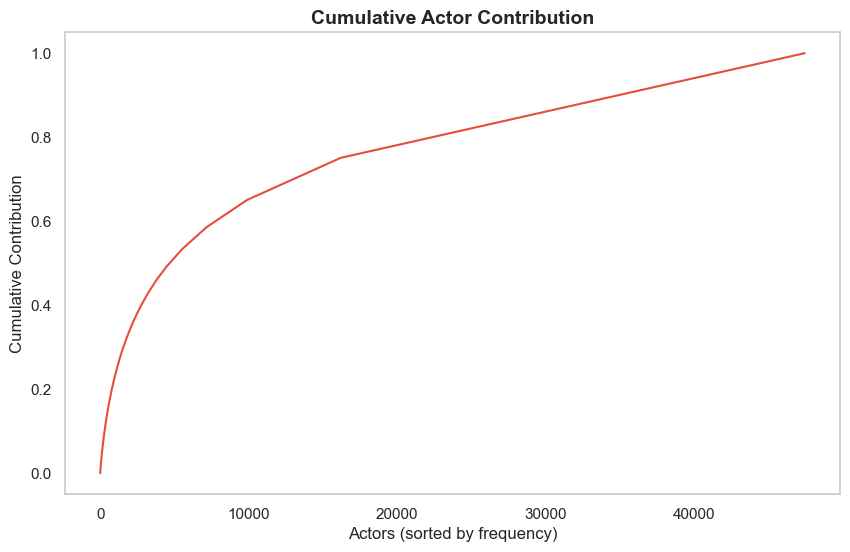

In [43]:
actor_counts = actor_series.value_counts().sort_values(ascending=False)

cumulative = actor_counts.cumsum() / actor_counts.sum()

plt.figure()

plt.plot(cumulative.values, color="#e74c3c")

plt.title("Cumulative Actor Contribution", fontsize=14, fontweight='bold')
plt.xlabel("Actors (sorted by frequency)")
plt.ylabel("Cumulative Contribution")

plt.grid()

plt.show()

In [34]:
print("🎬 FINAL PROJECT SUMMARY\n")

# Actor insights
unique_actors = len(actor_series.unique())
top_actor_name = top_actors.index[0]
top_actor_count = top_actors.iloc[0]

# Director insights
unique_directors = df['director'].nunique()
top_director_name = df['director'].value_counts().index[0]
top_director_count = df['director'].value_counts().iloc[0]

# Cast insights
avg_cast = round(df['cast_size'].mean(), 2)
max_cast = df['cast_size'].max()
min_cast = df['cast_size'].min()

# Dominance insight
top10_total = top_actors.sum()
all_total = actor_series.count()
percentage = round((top10_total / all_total) * 100, 2)

print("🎭 ACTOR INSIGHTS")
print(f"• Total Unique Actors: {unique_actors}")
print(f"• Most Frequent Actor: {top_actor_name} ({top_actor_count} movies)\n")

print("🎬 DIRECTOR INSIGHTS")
print(f"• Total Unique Directors: {unique_directors}")
print(f"• Most Active Director: {top_director_name} ({top_director_count} movies)\n")

print("📏 CAST SIZE INSIGHTS")
print(f"• Average Cast Size: {avg_cast}")
print(f"• Max Cast Size: {max_cast}")
print(f"• Min Cast Size: {min_cast}\n")

print("📊 INDUSTRY PATTERN")
print(f"• Top 10 actors contribute {percentage}% of total appearances")
print("• Indicates strong dominance (power-law behavior)\n")

print("🎯 CONCLUSION")
print("""
The movie industry is highly skewed:
- A small group of actors dominate appearances
- Most directors work on very few films
- Cast sizes are generally moderate
- Strong imbalance reflects real-world industry concentration
""")

🎬 FINAL PROJECT SUMMARY

🎭 ACTOR INSIGHTS
• Total Unique Actors: 47481
• Most Frequent Actor: John Wayne (106 movies)

🎬 DIRECTOR INSIGHTS
• Total Unique Directors: 17572
• Most Active Director: John Ford (66 movies)

📏 CAST SIZE INSIGHTS
• Average Cast Size: 12.37
• Max Cast Size: 313
• Min Cast Size: 0

📊 INDUSTRY PATTERN
• Top 10 actors contribute 0.63% of total appearances
• Indicates strong dominance (power-law behavior)

🎯 CONCLUSION

The movie industry is highly skewed:
- A small group of actors dominate appearances
- Most directors work on very few films
- Cast sizes are generally moderate
- Strong imbalance reflects real-world industry concentration

